# Call Center Scheduling
*for instructions see HW1 in BRUTE*

In [1]:
!pip install gurobipy
%matplotlib inline
import gurobipy as g
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
d = [6, 6, 6, 6, 6, 8, 9, 12, 18, 22, 25, 21, 21, 20, 18, 21, 21, 24, 24, 18, 18, 18, 12, 8]

In [6]:
# Gurobi model for the example problem
import gurobipy as g  # import Gurobi

# Input data ----------------------
# The program above

n = len(d)
x = [0]*n

# Model ---------------------------
m = g.Model()  # create an empty model
# - variables
for i in range(n):
    x[i] = m.addVar(vtype=g.GRB.INTEGER)

# - constraints
for i in range(n):
    workers = g.quicksum(x[(i-k) % 24] for k in range(8)) 
    m.addConstr((workers >= d[i]))

# - objective
# method setObjective is used to set objective
m.setObjective(g.quicksum(x[i] for i in range(n)), g.GRB.MINIMIZE)

m.optimize()

# Solution ------------------------
for i in range(len(x)):
  print(x[i].X)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads



Optimize a model with 24 rows, 24 columns and 192 nonzeros (Min)
Model fingerprint: 0x71dbed7a
Model has 24 linear objective coefficients
Variable types: 0 continuous, 24 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 3e+01]

Found heuristic solution: objective 58.0000000
Presolve time: 0.02s
Presolved: 24 rows, 24 columns, 192 nonzeros
Variable types: 0 continuous, 24 integer (0 binary)

Root relaxation: objective 5.500000e+01, 14 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0      55.0000000   55.00000  0.00%     -    0s

Explored 1 nodes (14 simplex iterations) in 0.09 seconds (0.00 work units)
Thread count was 8 (of 8 available processors)

Solution count 2: 55 58 

Optimal solution fo

[6.0, 0.0, 0.0, 6.0, 6.0, 8.0, 12.0, 12.0, 18.0, 22.0, 22.0, 21.0, 21.0, 19.0, 18.0, 21.0, 21.0, 23.0, 23.0, 18.0, 18.0, 18.0, 15.0, 12.0]


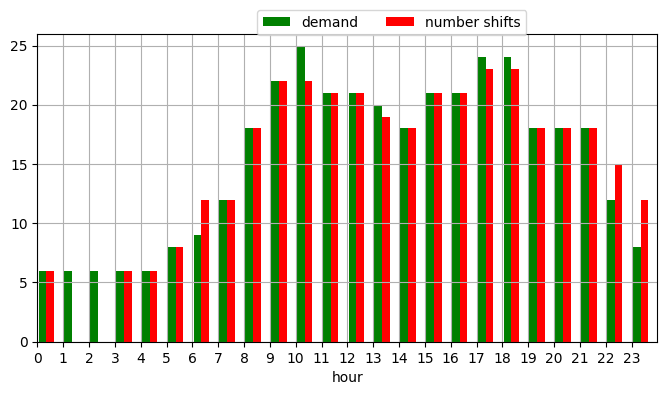

In [12]:
def plot_shifts(x_start):
    num_shifts = [sum([x_start[k % 24] for k in range(i-7, i+1)]) for i in range(24)]
    print(num_shifts)
    margin = 0.2
    width = 0.3
    plt.figure(figsize=(8, 4))
    plt.bar([h + margin for h in range(24)], d, width=width, color='green')
    plt.bar([h + margin + width for h in range(24)], num_shifts, width=width, color='red')
    plt.xlabel("hour")
    plt.legend(['demand', 'number shifts'], ncol=2, bbox_to_anchor=(0.8, 1.1))
    plt.xlim(0, 24)
    plt.ylim(0, max(num_shifts + d) + 1)
    plt.xticks(range(24), [i % 24 for i in range(24)])
    plt.grid()
    plt.show()

plot_shifts([x[i].x for i in range(24)])

In [33]:
# Gurobi model for the example problem
import gurobipy as g  # import Gurobi

# Input data ----------------------
# The program above

n = len(d)
x = [0]*n
z = [0]*n


# Model ---------------------------
m = g.Model()  # create an empty model
# - variables
for i in range(n):
    x[i] = m.addVar(vtype=g.GRB.INTEGER)
    z[i] = m.addVar(vtype=g.GRB.CONTINUOUS)

# - constraints
for i in range(n):
    workers = g.quicksum(x[(i-k) % 24] for k in range(8)) 
    m.addConstr((workers >= d[i]))

for i in range(n):
    m.addConstr(d[i] - g.quicksum(x[(i-k) % 24] for k in range(8)) <= z[i])
    m.addConstr(g.quicksum(x[(i-k) % 24] for k in range(8)) - d[i] <= z[i])

# - objective
# method setObjective is used to set objective
m.setObjective(g.quicksum(z[i] for i in range(n)), g.GRB.MINIMIZE)

m.optimize()

# Solution ------------------------
for i in range(len(x)):
  print(x[i].X)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 72 rows, 48 columns and 624 nonzeros (Min)
Model fingerprint: 0x4d2dbccd
Model has 24 linear objective coefficients
Variable types: 24 continuous, 24 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 3e+01]

Found heuristic solution: objective 144.0000000
Presolve removed 48 rows and 24 columns
Presolve time: 0.00s
Presolved: 24 rows, 24 columns, 192 nonzeros
Variable types: 0 continuous, 24 integer (0 binary)
Found heuristic solution: objective 88.0000000

Root relaxation: objective 7.200000e+01, 13 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objecti

[6.0, 6.0, 6.0, 16.0, 16.0, 17.0, 25.0, 25.0, 25.0, 25.0, 25.0, 21.0, 21.0, 20.0, 18.0, 22.0, 24.0, 24.0, 24.0, 18.0, 18.0, 18.0, 12.0, 8.0]


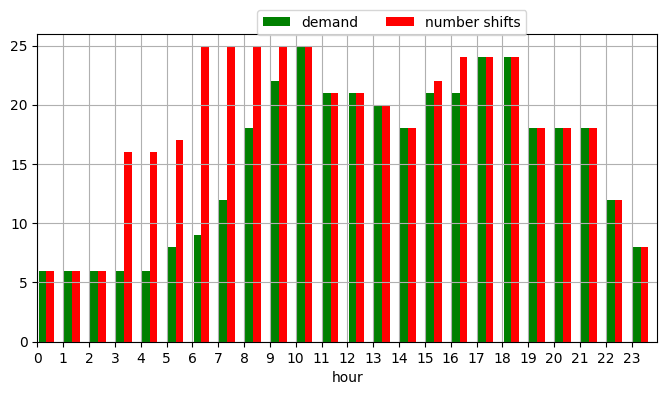

In [34]:
plot_shifts([x[i].x for i in range(24)])

In [31]:
# Gurobi model for the example problem
import gurobipy as g  # import Gurobi

# Input data ----------------------
# The program above

n = len(d)
# x = [0]*n
# z = [0]*n


# Model ---------------------------
m = g.Model()  # create an empty model
# - variables
for i in range(n):
    x[i] = m.addVar(vtype=g.GRB.INTEGER)
    z[i] = m.addVar(vtype=g.GRB.CONTINUOUS)

# x = m.addVars(24, vtype=g.GRB.INTEGER)
# z = m.addVars(24, vtype=g.GRB.CONTINUOUS)

# - constraints
# for i in range(n):
#     workers = g.quicksum(x[(i-k) % 24] for k in range(8)) 
#     m.addConstr((workers >= d[i]))

for i in range(n):
    # coverage = g.quicksum(x[(i - k) % 24] for k in range(8))
    m.addConstr(d[i] - g.quicksum(x[(i-k) % 24] for k in range(8)) <= z[i])
    # m.addConstr(d[i] - coverage <= z[i])
    m.addConstr(g.quicksum(x[(i-k) % 24] for k in range(8)) - d[i] <= z[i])
    # m.addConstr(coverage - d[i] <= z[i])

# - objective
# method setObjective is used to set objective
m.setObjective(g.quicksum(z[i] for i in range(n)), g.GRB.MINIMIZE)

m.optimize()

# Solution ------------------------
for i in range(len(x)):
  print(x[i].X)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 48 rows, 48 columns and 432 nonzeros (Min)
Model fingerprint: 0xf48812a2
Model has 24 linear objective coefficients
Variable types: 24 continuous, 24 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 3e+01]

Found heuristic solution: objective 368.0000000
Presolve time: 0.00s
Presolved: 48 rows, 48 columns, 432 nonzeros
Variable types: 0 continuous, 48 integer (0 binary)

Root relaxation: objective 2.800000e+01, 31 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap

In [ ]:
plot_shifts([x[i].x for i in range(24)])

In [ ]:
plot_shifts([x[i].x for i in range(24)])

In [ ]:
m = g.Model()

# Create auxiliary variables z[i]
x = m.addVars(24, vtype=g.GRB.INTEGER, name="x")
z = m.addVars(24, vtype=g.GRB.CONTINUOUS, name="z")

# Add constraints for the absolute value linearization
for i in range(24):
    coverage = g.quicksum(x[(i - k) % 24] for k in range(8))
    
    # z[i] >= d[i] - coverage
    m.addConstr(z[i] >= (d[i] - coverage))
    
    # z[i] >= coverage - d[i]
    m.addConstr(z[i] >= (coverage - d[i]))

# Set objective to minimize the sum of z
m.setObjective(z.sum(), g.GRB.MINIMIZE)

m.optimize()

for i in range(len(x)):
  print(x[i].X)

In [ ]:
plot_shifts([x[i].x for i in range(24)])

In [ ]:
# Gurobi model for the example problem
import gurobipy as g  # import Gurobi

# Input data ----------------------
# The program above

n = len(d)
D = 2

x = [0]*n
z = [0]*n


# Model ---------------------------
m = g.Model()  # create an empty model
# - variables
for i in range(n):
    x[i] = m.addVar(vtype=g.GRB.INTEGER)
    z[i] = m.addVar(vtype=g.GRB.CONTINUOUS)

# - constraints
for i in range(n):
    m.addConstr(d[i] - g.quicksum(x[(i-k) % 24] for k in range(8)) <= z[i])
    m.addConstr(g.quicksum(x[(i-k) % 24] for k in range(8)) - d[i] <= z[i])
    m.addConstr(d[i] - g.quicksum(x[(i-k) % 24] for k in range(8)) <= D)

# - objective
# method setObjective is used to set objective
m.setObjective(g.quicksum(z[i] for i in range(n)), g.GRB.MINIMIZE)

m.optimize()

# Solution ------------------------
for i in range(len(x)):
  print(x[i].X)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 72 rows, 48 columns and 624 nonzeros (Min)
Model fingerprint: 0xf019884e
Model has 24 linear objective coefficients
Variable types: 24 continuous, 24 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 3e+01]

Found heuristic solution: objective 98.0000000
Presolve time: 0.00s
Presolved: 72 rows, 48 columns, 624 nonzeros
Variable types: 0 continuous, 48 integer (0 binary)

Root relaxation: objective 4.200000e+01, 41 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap 

[8.0, 4.0, 4.0, 7.0, 7.0, 8.0, 19.0, 20.0, 20.0, 22.0, 23.0, 21.0, 21.0, 20.0, 18.0, 21.0, 21.0, 23.0, 22.0, 21.0, 21.0, 21.0, 12.0, 8.0]


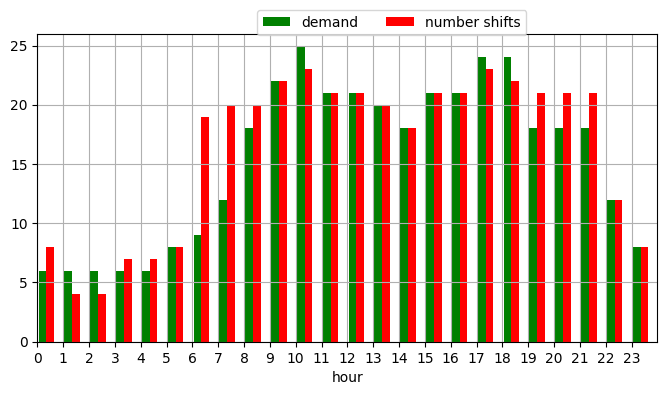

In [40]:
plot_shifts([x[i].x for i in range(24)])

In [ ]:
# Gurobi model for the example problem
import gurobipy as g  # import Gurobi

# Input data ----------------------
# The program above
d = [6, 6, 6, 6, 6, 8, 9, 12, 18, 22, 25, 21, 21, 20, 18, 21, 21, 24, 24, 18, 18, 18, 12, 8]
e = [3, 3, 3, 3, 3, 4, 4, 6, 9, 11, 12, 10, 10, 10, 9, 10, 10, 12, 12, 9, 9, 9, 6, 4]

full_demand = d * 5 + e * 2

n = len(full_demand)
# print(n)
D = 2

x = [0]*n
z = [0]*n


# Model ---------------------------
m = g.Model()  # create an empty model
# - variables
for i in range(n):
    x[i] = m.addVar(vtype=g.GRB.INTEGER)
    z[i] = m.addVar(vtype=g.GRB.CONTINUOUS)

# - constraints
for i in range(n):
    coverage = g.quicksum(x[(i-k) % 168] for k in range(8))
    d = full_demand[i]
    m.addConstr(d - coverage <= z[i])
    m.addConstr(coverage - d <= z[i])
    m.addConstr(d - coverage <= D)

# - objective
# method setObjective is used to set objective
m.setObjective(g.quicksum(z[i] for i in range(n)), g.GRB.MINIMIZE)

m.optimize()

# Solution ------------------------
for i in range(len(x)):
  print(x[i].X)

Set parameter Username
Set parameter LicenseID to value 2780105
Academic license - for non-commercial use only - expires 2027-02-17
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1135G7 @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 504 rows, 336 columns and 4368 nonzeros (Min)
Model fingerprint: 0x209061e3
Model has 168 linear objective coefficients
Variable types: 168 continuous, 168 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 3e+01]

Found heuristic solution: objective 870.0000000
Presolve time: 0.02s
Presolved: 504 rows, 336 columns, 4368 nonzeros
Variable types: 0 continuous, 336 integer (0 binary)

Root relaxation: objective 2.320000e+02, 442 iterations, 0.01 seconds (0.00 work